# 🧬 Bio-JEPA — Baseline AttrMasking (Hu et al. 2020)

**Objectif** : Entraîner la baseline SSL AttrMasking (Attribute Masking) de Hu et al. [ICLR 2020]  
et l'évaluer en few-shot sur ChEMBL251 (A2A) pour comparaison directe avec Bio-JEPA.

---

## Pourquoi AttrMasking ?

AttrMasking est la baseline SSL moléculaire la plus proche de Bio-JEPA :
- Apprentissage auto-supervisé sur graphes moléculaires
- Pré-entraînement sans labels biologiques
- Même protocole few-shot possible
- Référence standard dans la littérature (Hu et al. 2020, ICLR)

**Différence clé avec Bio-JEPA** : AttrMasking prédit dans l'espace *brut* (attributs masqués),  
Bio-JEPA prédit dans l'espace *latent* (représentation encodée).

---

## Plan
| Étape | Description | Durée |
|---|---|---|
| 0 | Vérification GPU | 1 min |
| 1 | Montage Drive + Clone repo | 2 min |
| 2 | Installation dépendances | 3 min |
| 3 | Implémentation AttrMasking | — |
| 4 | Pré-entraînement ZINC250k | ~45 min |
| 5 | Few-shot eval ChEMBL251 (A2A) | ~30 min |
| 6 | Sauvegarde résultats + comparaison | 2 min |

---
## Étape 0 — Vérification GPU

In [1]:
import torch
!nvidia-smi
print(f'\n✓ PyTorch : {torch.__version__}')
print(f'✓ CUDA disponible : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'✓ GPU : {torch.cuda.get_device_name(0)}')
    print(f'✓ VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Wed Mar 11 12:26:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             41W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

---
## Étape 1 — Montage Drive + Clone repo

In [2]:
from google.colab import drive
import os, shutil

drive.mount('/content/drive')

DRIVE_CKPT    = '/content/drive/MyDrive/Bio-JEPA-checkpoints'
DRIVE_RESULTS = '/content/drive/MyDrive/Bio-JEPA-results'
os.makedirs(DRIVE_CKPT, exist_ok=True)
os.makedirs(DRIVE_RESULTS, exist_ok=True)

print('✓ Google Drive monté')
print(f'✓ Checkpoints : {DRIVE_CKPT}')
print(f'✓ Résultats   : {DRIVE_RESULTS}')

Mounted at /content/drive
✓ Google Drive monté
✓ Checkpoints : /content/drive/MyDrive/Bio-JEPA-checkpoints
✓ Résultats   : /content/drive/MyDrive/Bio-JEPA-results


In [7]:
!git clone https://github.com/7Nayy/Bio-JEPA.git /content/Bio-JEPA
%cd /content/Bio-JEPA
!ls -la

Cloning into '/content/Bio-JEPA'...
remote: Enumerating objects: 123, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 123 (delta 22), reused 50 (delta 13), pack-reused 54 (from 2)
Receiving objects: 100% (123/123), 48.14 MiB | 31.87 MiB/s, done.
Resolving deltas: 100% (25/25), done.
/content/Bio-JEPA
total 860
drwxr-xr-x 11 root root   4096 Mar 11 12:28 .
drwxr-xr-x  1 root root   4096 Mar 11 12:28 ..
-rw-r--r--  1 root root  19602 Mar 11 12:28 ablation_study.py
-rw-r--r--  1 root root  29787 Mar 11 12:28 autodock_benchmark.py
-rw-r--r--  1 root root  22223 Mar 11 12:28 baseline.py
drwxr-xr-x  2 root root   4096 Mar 11 12:28 checkpoints
-rw-r--r--  1 root root   4230 Mar 11 12:28 CLAUDE.md
drwxr-xr-x  2 root root   4096 Mar 11 12:28 configs
drwxr-xr-x  4 root root   4096 Mar 11 12:28 data
drwxr-xr-x  3 root root   4096 Mar 11 12:28 evaluation
-rw-r--r--  1 root root  37672 Mar 11 12:28 few_shot_eval.py
drwxr-xr-x  8 roo

---
## Étape 2 — Installation des dépendances

In [8]:
!pip install torch_geometric rdkit pandas numpy scikit-learn tqdm requests pyyaml chembl-webresource-client -q
print('✓ Dépendances installées')

✓ Dépendances installées


---
## Étape 3 — Implémentation AttrMasking

**Principe (Hu et al. 2020)** :
1. Masquer aléatoirement des attributs de nœuds (features atomiques)
2. Entraîner un GNN à prédire les attributs masqués depuis le contexte du graphe
3. La perte est une cross-entropy sur les classes d'atomes masqués

Implémentation autonome — **pas besoin d'importer le repo original de Hu et al.**

In [9]:
# ============================================================
# AttrMasking — Implémentation complète
# Basée sur Hu et al. (2020) "Strategies for Pre-training
# Graph Neural Networks" ICLR 2020
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINEConv, global_mean_pool
from torch_geometric.data import Data, DataLoader
import numpy as np
import random

# --- Dimensions (identiques à Bio-JEPA pour comparaison équitable) ---
NODE_FEAT_DIM  = 29   # features par atome (même que Bio-JEPA)
EDGE_FEAT_DIM  = 7    # features par liaison (même que Bio-JEPA)
HIDDEN_DIM     = 256  # dimension cachée
EMBEDDING_DIM  = 256  # dimension de l'embedding final
NUM_GNN_LAYERS = 5    # profondeur GNN
MASK_RATIO     = 0.15 # 15% des nœuds masqués (standard Hu et al.)
MASK_TOKEN     = -1.0 # valeur de remplacement des features masquées


class AttrMaskingEncoder(nn.Module):
    """GNN encoder partagé entre AttrMasking et la tête de prédiction."""

    def __init__(self, node_feat_dim, edge_feat_dim, hidden_dim,
                 embedding_dim, num_layers):
        super().__init__()
        self.node_embed = nn.Linear(node_feat_dim, hidden_dim)
        self.edge_embed = nn.Linear(edge_feat_dim, hidden_dim)

        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()
        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, 2 * hidden_dim),
                nn.ReLU(),
                nn.Linear(2 * hidden_dim, hidden_dim)
            )
            self.convs.append(GINEConv(mlp))
            self.bns.append(nn.BatchNorm1d(hidden_dim))

        self.proj = nn.Linear(hidden_dim, embedding_dim)

    def forward(self, x, edge_index, edge_attr, batch):
        x        = self.node_embed(x)
        edge_attr = self.edge_embed(edge_attr)

        for conv, bn in zip(self.convs, self.bns):
            x = bn(F.relu(conv(x, edge_index, edge_attr)))

        # Embedding niveau graphe
        graph_emb = global_mean_pool(x, batch)
        return self.proj(graph_emb), x  # (graph_emb, node_emb)


class AttrMaskingModel(nn.Module):
    """Modèle complet AttrMasking : encoder + tête de reconstruction."""

    def __init__(self, node_feat_dim=NODE_FEAT_DIM, edge_feat_dim=EDGE_FEAT_DIM,
                 hidden_dim=HIDDEN_DIM, embedding_dim=EMBEDDING_DIM,
                 num_layers=NUM_GNN_LAYERS):
        super().__init__()
        self.encoder = AttrMaskingEncoder(
            node_feat_dim, edge_feat_dim, hidden_dim, embedding_dim, num_layers
        )
        # Tête de reconstruction : prédit les features originales
        # pour chaque nœud masqué
        self.reconstruction_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, node_feat_dim)
        )

    def forward(self, x, edge_index, edge_attr, batch, masked_indices):
        _, node_emb = self.encoder(x, edge_index, edge_attr, batch)
        # Prédire les features des nœuds masqués
        masked_emb = node_emb[masked_indices]
        pred = self.reconstruction_head(masked_emb)
        return pred

    def get_graph_embedding(self, x, edge_index, edge_attr, batch):
        """Interface pour l'évaluation few-shot."""
        graph_emb, _ = self.encoder(x, edge_index, edge_attr, batch)
        return graph_emb


def mask_node_attributes(data, mask_ratio=MASK_RATIO):
    """
    Masque aléatoirement mask_ratio des nœuds.
    Retourne : (x_masked, masked_indices, original_features)
    """
    num_nodes = data.x.size(0)
    n_masked  = max(1, int(num_nodes * mask_ratio))
    masked_indices = torch.tensor(
        random.sample(range(num_nodes), n_masked),
        dtype=torch.long
    )
    # Sauvegarder les features originales
    original_features = data.x[masked_indices].clone()
    # Remplacer par le token de masque
    x_masked = data.x.clone()
    x_masked[masked_indices] = MASK_TOKEN
    return x_masked, masked_indices, original_features


print('✓ Modèle AttrMasking défini')
print(f'  Architecture : GIN {NUM_GNN_LAYERS} couches, hidden={HIDDEN_DIM}, emb={EMBEDDING_DIM}')
print(f'  Mask ratio   : {MASK_RATIO:.0%}')

# Compter les paramètres
model_tmp = AttrMaskingModel()
n_params = sum(p.numel() for p in model_tmp.parameters() if p.requires_grad)
print(f'  Paramètres   : {n_params:,}')
del model_tmp

✓ Modèle AttrMasking défini
  Architecture : GIN 5 couches, hidden=256, emb=256
  Mask ratio   : 15%
  Paramètres   : 1,465,885


---
## Étape 4 — Pré-entraînement AttrMasking sur ZINC250k

In [23]:
%cd /content/Bio-JEPA
import sys, os, torch, shutil, pandas as pd
sys.path.insert(0, '/content/Bio-JEPA')
from data.mol_graph import smiles_vers_graphe
from tqdm import tqdm

DRIVE_CKPT = '/content/drive/MyDrive/Bio-JEPA-checkpoints'
ZINC_CACHE = 'data/zinc_graphs.pt'

# Parser avec pandas — gère les guillemets automatiquement
url = 'https://raw.githubusercontent.com/aspuru-guzik-group/chemical_vae/master/models/zinc_properties/250k_rndm_zinc_drugs_clean_3.csv'
df = pd.read_csv(url)
print(f"Colonnes : {df.columns.tolist()}")
print(f"Shape : {df.shape}")
print(f"Exemple SMILES : {df['smiles'].iloc[0]}")
print(f"Exemple SMILES 2 : {df['smiles'].iloc[1]}")

# Conversion en graphes
smiles_list = df['smiles'].dropna().tolist()
graphs, errors = [], 0
for smi in tqdm(smiles_list[:250000]):
    try:
        g = smiles_vers_graphe(smi.strip())
        if g is not None:
            graphs.append(g)
    except Exception:
        errors += 1

print(f'\n✓ {len(graphs):,} graphes | {errors} erreurs')

# Sauvegarder local + Drive
os.makedirs('data', exist_ok=True)
torch.save(graphs, ZINC_CACHE)
shutil.copy(ZINC_CACHE, f'{DRIVE_CKPT}/zinc_graphs.pt')
print(f'✓ Sauvegardé : {ZINC_CACHE} + Drive')

/content/Bio-JEPA
Colonnes : ['smiles', 'logP', 'qed', 'SAS']
Shape : (249455, 4)
Exemple SMILES : CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1

Exemple SMILES 2 : C[C@@H]1CC(Nc2cncc(-c3nncn3C)c2)C[C@@H](C)C1



100%|██████████| 249455/249455 [03:38<00:00, 1139.28it/s]



✓ 249,455 graphes | 0 erreurs
✓ Sauvegardé : data/zinc_graphs.pt + Drive


In [25]:
%cd /content/Bio-JEPA
import sys, os, torch, shutil, pandas as pd
sys.path.insert(0, '/content/Bio-JEPA')
from data.mol_graph import smiles_vers_graphe
from torch_geometric.data import DataLoader
from tqdm import tqdm

DRIVE_CKPT = '/content/drive/MyDrive/Bio-JEPA-checkpoints'
ZINC_CACHE = 'data/zinc_graphs.pt'
os.makedirs('data', exist_ok=True)

# --- Charger depuis Drive si déjà sauvegardé ---
if os.path.exists(f'{DRIVE_CKPT}/zinc_graphs.pt'):
    print('⬇ zinc_graphs.pt trouvé sur Drive, vérification...')
    zinc_graphs = torch.load(f'{DRIVE_CKPT}/zinc_graphs.pt', weights_only=False)
    print(f'  → {len(zinc_graphs)} graphes')
    if len(zinc_graphs) == 0:
        print('⚠ Fichier vide sur Drive — régénération...')
        zinc_graphs = None

if 'zinc_graphs' not in dir() or zinc_graphs is None or len(zinc_graphs) == 0:
    print('Téléchargement + parsing CSV...')
    url = 'https://raw.githubusercontent.com/aspuru-guzik-group/chemical_vae/master/models/zinc_properties/250k_rndm_zinc_drugs_clean_3.csv'
    df = pd.read_csv(url)
    print(f'CSV shape: {df.shape}')
    print(f'Colonnes: {df.columns.tolist()}')
    print(f'Exemples SMILES:\n{df["smiles"].head(3).tolist()}')

    graphs, errors = [], 0
    for smi in tqdm(df['smiles'].dropna().tolist()):
        try:
            g = smiles_vers_graphe(smi.strip())
            if g is not None:
                graphs.append(g)
            else:
                errors += 1
        except Exception as e:
            errors += 1

    print(f'\n✓ {len(graphs):,} graphes | {errors} erreurs')

    if len(graphs) == 0:
        # Debug — tester sur les 3 premiers SMILES manuellement
        print('\nDEBUG — test manuel:')
        for smi in df['smiles'].head(3).tolist():
            print(f'  SMILES: {repr(smi)}')
            try:
                g = smiles_vers_graphe(smi.strip())
                print(f'  → {g}')
            except Exception as e:
                print(f'  → ERREUR: {e}')
    else:
        torch.save(graphs, ZINC_CACHE)
        shutil.copy(ZINC_CACHE, f'{DRIVE_CKPT}/zinc_graphs.pt')
        print(f'✓ Sauvegardé local + Drive')
        zinc_graphs = graphs

# --- DataLoaders ---
BATCH_SIZE = 256
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_val   = int(0.1 * len(zinc_graphs))
n_train = len(zinc_graphs) - n_val
train_loader = DataLoader(zinc_graphs[:n_train], batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(zinc_graphs[n_train:], batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f'\n✓ Train: {n_train:,} | Val: {n_val:,} | Device: {DEVICE}')

/content/Bio-JEPA
⬇ zinc_graphs.pt trouvé sur Drive, vérification...
  → 249455 graphes

✓ Train: 224,510 | Val: 24,945 | Device: cuda


/tmp/ipykernel_1204/1649057051.py:63: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(zinc_graphs[:n_train], batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
/tmp/ipykernel_1204/1649057051.py:64: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader   = DataLoader(zinc_graphs[n_train:], batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


In [26]:
# --- Entraînement ---
model     = AttrMaskingModel().to(DEVICE)
optimizer = Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=PRETRAIN_EPOCHS)
criterion = nn.MSELoss()  # reconstruction L2 sur les features

best_val_loss = float('inf')
history = []

print(f'Pré-entraînement AttrMasking — {PRETRAIN_EPOCHS} époques')
print('='*60)

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    # --- Train ---
    model.train()
    train_loss = 0.0
    t0 = time.time()

    for batch in train_loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()

        # Masquer les attributs de nœuds
        # On traite chaque graphe du batch individuellement
        all_preds, all_targets = [], []

        # Approche vectorisée : masquage global sur le batch
        num_nodes = batch.x.size(0)
        n_masked  = max(1, int(num_nodes * MASK_RATIO))
        masked_idx = torch.randperm(num_nodes, device=DEVICE)[:n_masked]

        original_features = batch.x[masked_idx].clone()
        x_masked = batch.x.clone()
        x_masked[masked_idx] = MASK_TOKEN

        # Forward
        batch_masked = batch.clone()
        batch_masked.x = x_masked
        pred = model(batch_masked.x, batch_masked.edge_index,
                     batch_masked.edge_attr, batch_masked.batch,
                     masked_idx)

        loss = criterion(pred, original_features)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    scheduler.step()

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(DEVICE)
            num_nodes = batch.x.size(0)
            n_masked  = max(1, int(num_nodes * MASK_RATIO))
            masked_idx = torch.randperm(num_nodes, device=DEVICE)[:n_masked]
            original_features = batch.x[masked_idx].clone()
            x_masked = batch.x.clone()
            x_masked[masked_idx] = MASK_TOKEN
            batch_masked = batch.clone()
            batch_masked.x = x_masked
            pred = model(batch_masked.x, batch_masked.edge_index,
                         batch_masked.edge_attr, batch_masked.batch,
                         masked_idx)
            val_loss += criterion(pred, original_features).item()
    val_loss /= len(val_loader)

    # Sauvegarder le meilleur modèle
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'checkpoints/attrmasking_pretrained.pt')

    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})

    if epoch % 10 == 0 or epoch == 1:
        elapsed = time.time() - t0
        print(f'Ep {epoch:3d}/{PRETRAIN_EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | Best: {best_val_loss:.4f} | {elapsed:.1f}s')

print('\n✓ Pré-entraînement terminé')
print(f'  Meilleure val loss : {best_val_loss:.4f}')

# Sauvegarder sur Drive
shutil.copy('checkpoints/attrmasking_pretrained.pt',
            f'{DRIVE_CKPT}/attrmasking_pretrained.pt')
print(f'✓ Checkpoint sauvegardé sur Drive')

Pré-entraînement AttrMasking — 100 époques
Ep   1/100 | Train: 0.0122 | Val: 0.0096 | Best: 0.0096 | 15.7s
Ep  10/100 | Train: 0.0070 | Val: 0.0073 | Best: 0.0073 | 14.6s
Ep  20/100 | Train: 0.0064 | Val: 0.0066 | Best: 0.0066 | 14.4s
Ep  30/100 | Train: 0.0062 | Val: 0.0065 | Best: 0.0063 | 14.6s
Ep  40/100 | Train: 0.0060 | Val: 0.0060 | Best: 0.0059 | 14.3s
Ep  50/100 | Train: 0.0058 | Val: 0.0058 | Best: 0.0058 | 14.2s
Ep  60/100 | Train: 0.0056 | Val: 0.0056 | Best: 0.0056 | 14.5s
Ep  70/100 | Train: 0.0053 | Val: 0.0054 | Best: 0.0053 | 14.6s
Ep  80/100 | Train: 0.0051 | Val: 0.0051 | Best: 0.0051 | 14.8s
Ep  90/100 | Train: 0.0050 | Val: 0.0049 | Best: 0.0049 | 14.7s
Ep 100/100 | Train: 0.0049 | Val: 0.0050 | Best: 0.0049 | 14.4s

✓ Pré-entraînement terminé
  Meilleure val loss : 0.0049
✓ Checkpoint sauvegardé sur Drive


In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Étape 5 — Few-shot eval ChEMBL251 (A2A)

**Protocole identique à Bio-JEPA** :
- Encodeur AttrMasking gelé (frozen)
- Sonde MLP légère entraînée sur N exemples labelisés
- N ∈ {10, 50, 100, 200, 500, 1000}, 5 runs chacun
- Métrique : Pearson r sur le test set

In [34]:
# ============================================================
# CELLULE : Téléchargement ChEMBL251 — pagination corrigée
# ============================================================
import sys
sys.path.insert(0, '/content/Bio-JEPA')

import torch
import pandas as pd
import requests
from pathlib import Path
from data.mol_graph import smiles_vers_graphe

CHEMBL_CACHE = 'data/chembl251_graphs.pt'
Path('data').mkdir(exist_ok=True)

BASE_ROOT = 'https://www.ebi.ac.uk'

print('⬇ Téléchargement ChEMBL251 via API...')
records = []
url = (
    BASE_ROOT +
    '/chembl/api/data/activity.json'
    '?target_chembl_id=CHEMBL251'
    '&pchembl_value__isnull=false'
    '&limit=500&offset=0'
)

page = 0
while url:
    r = requests.get(url, timeout=60, headers={'Accept': 'application/json'})
    if r.status_code != 200:
        print(f'⚠ Erreur HTTP {r.status_code} sur {url}')
        break

    data = r.json()

    for act in data.get('activities', []):
        smi = act.get('canonical_smiles')
        val = act.get('pchembl_value')
        if smi and val:
            try:
                records.append({'smiles': smi, 'pchembl_value': float(val)})
            except (ValueError, TypeError):
                pass

    # next est un path absolu depuis la racine : /chembl/api/data/activity?...
    next_path = data.get('page_meta', {}).get('next')
    if next_path:
        # S'assurer qu'on n'a pas de .json dupliqué
        url = BASE_ROOT + next_path
        if '.json' not in url.split('?')[0]:
            url = url.replace('/activity?', '/activity.json?')
    else:
        url = None

    page += 1
    print(f'  Page {page} — {len(records)} activités...', end='\r')

df = pd.DataFrame(records).drop_duplicates('smiles')
print(f'\n✓ {len(df)} molécules uniques ({len(records)} activités brutes)')
df.to_csv('data/chembl251.csv', index=False)

# --- Génération des graphes ---
print('⚙ Conversion SMILES → graphes...')
data_list, errors = [], 0
for _, row in df.iterrows():
    try:
        g = smiles_vers_graphe(row['smiles'])
        if g is not None:
            g.y = torch.tensor([row['pchembl_value']], dtype=torch.float)
            data_list.append(g)
    except Exception:
        errors += 1

torch.save(data_list, CHEMBL_CACHE)
print(f'✓ {len(data_list):,} graphes → {CHEMBL_CACHE} ({errors} erreurs)')

import shutil
shutil.copy(CHEMBL_CACHE, '/content/drive/MyDrive/Bio-JEPA-checkpoints/chembl251_graphs.pt')
print('✓ Sauvegardé sur Drive')

⬇ Téléchargement ChEMBL251 via API...
  Page 18 — 8759 activités...
✓ 6710 molécules uniques (8759 activités brutes)
⚙ Conversion SMILES → graphes...
✓ 6,710 graphes → data/chembl251_graphs.pt (0 erreurs)
✓ Sauvegardé sur Drive


In [37]:
# ============================================================
# Few-shot evaluation AttrMasking
# Protocole identique à Bio-JEPA pour comparaison valide
# ============================================================

from scipy.stats import pearsonr, spearmanr
import json

# --- Chargement dataset ChEMBL251 ---
CHEMBL_CACHE = 'data/chembl251_graphs.pt'
if os.path.exists(CHEMBL_CACHE):
    chembl_data = torch.load(CHEMBL_CACHE, weights_only=False)

    print(f'✓ ChEMBL251 chargé : {len(chembl_data):,} molécules')
else:
    print('⚠ Cache ChEMBL absent — régénération...')
    !python data/mol_graph.py --source chembl --target 251
    chembl_data = torch.load(CHEMBL_CACHE)
    print(f'✓ ChEMBL251 généré : {len(chembl_data):,} molécules')

# Extraire les affinités
labels = torch.tensor([d.y.item() for d in chembl_data], dtype=torch.float32)
print(f'  Labels — min: {labels.min():.2f} | max: {labels.max():.2f} | mean: {labels.mean():.2f}')

✓ ChEMBL251 chargé : 6,710 molécules
  Labels — min: 3.39 | max: 11.00 | mean: 7.01


In [38]:
# --- Générer tous les embeddings AttrMasking une seule fois ---
# (encodeur gelé — pas de gradient)

# Charger le meilleur checkpoint
model.load_state_dict(torch.load('checkpoints/attrmasking_pretrained.pt'))
model.eval()
model = model.to(DEVICE)

all_embeddings = []
chembl_loader  = DataLoader(chembl_data, batch_size=512, shuffle=False)

with torch.no_grad():
    for batch in chembl_loader:
        batch = batch.to(DEVICE)
        emb = model.get_graph_embedding(
            batch.x, batch.edge_index, batch.edge_attr, batch.batch
        )
        all_embeddings.append(emb.cpu())

embeddings = torch.cat(all_embeddings, dim=0)  # (N_mol, EMBEDDING_DIM)
print(f'✓ Embeddings générés : {embeddings.shape}')

/tmp/ipykernel_1204/1120373185.py:10: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  chembl_loader  = DataLoader(chembl_data, batch_size=512, shuffle=False)


✓ Embeddings générés : torch.Size([6710, 256])


In [39]:
# --- Few-shot evaluation ---

class LinearProbe(nn.Module):
    """Sonde MLP légère — même architecture que Bio-JEPA few-shot."""
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


def few_shot_eval(embeddings, labels, N, n_runs=5, epochs=100, device=DEVICE):
    """Évalue la performance few-shot pour N exemples labelisés."""
    results = []
    n_total = len(embeddings)

    for run in range(n_runs):
        # Split aléatoire
        idx = torch.randperm(n_total)
        train_idx = idx[:N]
        test_idx  = idx[N:min(N + 1000, n_total)]  # max 1000 pour le test

        X_train = embeddings[train_idx].to(device)
        y_train = labels[train_idx].to(device)
        X_test  = embeddings[test_idx].to(device)
        y_test  = labels[test_idx].cpu().numpy()

        # Entraîner la sonde
        probe = LinearProbe(embeddings.size(1)).to(device)
        opt   = Adam(probe.parameters(), lr=1e-3)

        for _ in range(epochs):
            probe.train()
            opt.zero_grad()
            pred  = probe(X_train)
            loss  = F.mse_loss(pred, y_train)
            loss.backward()
            opt.step()

        # Évaluer
        probe.eval()
        with torch.no_grad():
            y_pred = probe(X_test).cpu().numpy()

        r, _  = pearsonr(y_test, y_pred)
        rho,_ = spearmanr(y_test, y_pred)
        rmse  = np.sqrt(np.mean((y_test - y_pred)**2))
        results.append({'pearson_r': r, 'spearman_r': rho, 'rmse': rmse})

    return {
        'N': N,
        'pearson_r': {
            'mean': float(np.mean([r['pearson_r'] for r in results])),
            'std':  float(np.std([r['pearson_r']  for r in results]))
        },
        'spearman_r': {
            'mean': float(np.mean([r['spearman_r'] for r in results])),
            'std':  float(np.std([r['spearman_r']  for r in results]))
        },
        'rmse': {
            'mean': float(np.mean([r['rmse'] for r in results])),
            'std':  float(np.std([r['rmse']  for r in results]))
        }
    }


# --- Lancer l'évaluation ---
N_VALUES = [10, 50, 100, 200, 500, 1000]
N_RUNS   = 5

attrmasking_results = []
print('Few-shot evaluation AttrMasking (ChEMBL251 — A2A)')
print('='*55)
print(f'{"N":>6} | {"Pearson r":>10} | {"Spearman ρ":>10} | {"RMSE":>8}')
print('-'*55)

for N in N_VALUES:
    res = few_shot_eval(embeddings, labels, N=N, n_runs=N_RUNS)
    attrmasking_results.append(res)
    r   = res['pearson_r']
    rho = res['spearman_r']
    rmse= res['rmse']
    print(f'{N:>6} | {r["mean"]:>8.3f}±{r["std"]:.3f} | {rho["mean"]:>8.3f}±{rho["std"]:.3f} | {rmse["mean"]:>6.3f}±{rmse["std"]:.3f}')

print('='*55)
print('✓ Évaluation terminée')

Few-shot evaluation AttrMasking (ChEMBL251 — A2A)
     N |  Pearson r | Spearman ρ |     RMSE
-------------------------------------------------------
    10 |    0.120±0.021 |    0.109±0.016 |  1.436±0.200
    50 |    0.128±0.011 |    0.121±0.013 |  1.362±0.133
   100 |    0.098±0.022 |    0.098±0.017 |  1.371±0.017
   200 |    0.102±0.020 |    0.097±0.023 |  1.362±0.043
   500 |    0.117±0.020 |    0.108±0.017 |  1.373±0.124
  1000 |    0.107±0.050 |    0.102±0.052 |  1.339±0.041
✓ Évaluation terminée


---
## Étape 6 — Sauvegarde + Comparaison Bio-JEPA vs AttrMasking

In [40]:
# --- Sauvegarder les résultats AttrMasking ---
output = {
    'baseline':     'AttrMasking',
    'reference':    'Hu et al. (2020), ICLR',
    'target':       'A2A (ChEMBL251)',
    'pretrain':     'ZINC250k 100 epochs',
    'N_values':     N_VALUES,
    'n_runs':       N_RUNS,
    'results':      attrmasking_results
}

os.makedirs('results', exist_ok=True)
with open('results/attrmasking_fewshot.json', 'w') as f:
    json.dump(output, f, indent=2)

shutil.copy('results/attrmasking_fewshot.json',
            f'{DRIVE_RESULTS}/attrmasking_fewshot.json')
print('✓ Résultats sauvegardés sur Drive')

✓ Résultats sauvegardés sur Drive


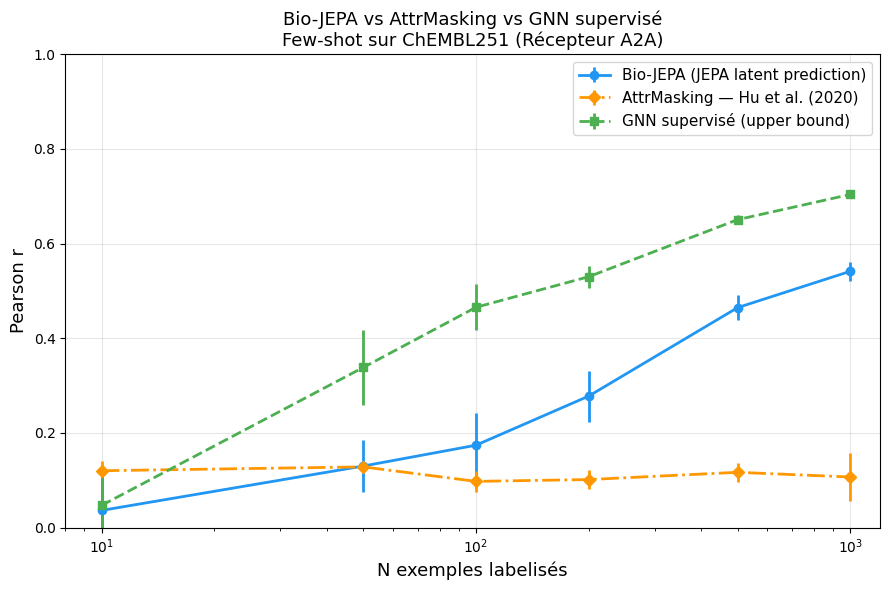

✓ Figure sauvegardée sur Drive


In [41]:
# --- Comparaison visuelle Bio-JEPA vs AttrMasking ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Charger les résultats Bio-JEPA
with open(f'{DRIVE_RESULTS}/few_shot_transfer.json') as f:
    jepa_data = json.load(f)

# Extraire les données
N_vals = N_VALUES

# Bio-JEPA (structure : bio_jepa[i] = {'mean_r', 'std_r'})
jepa_r   = [x['mean_r'] for x in jepa_data['bio_jepa']]
jepa_std = [x['std_r']  for x in jepa_data['bio_jepa']]
gnn_r    = [x['mean_r'] for x in jepa_data['gnn_supervise']]
gnn_std  = [x['std_r']  for x in jepa_data['gnn_supervise']]

# AttrMasking
attr_r   = [r['pearson_r']['mean'] for r in attrmasking_results]
attr_std = [r['pearson_r']['std']  for r in attrmasking_results]

fig, ax = plt.subplots(figsize=(9, 6))

ax.errorbar(N_vals, jepa_r,   yerr=jepa_std,  marker='o', linewidth=2,
            label='Bio-JEPA (JEPA latent prediction)', color='#2196F3')
ax.errorbar(N_vals, attr_r,   yerr=attr_std,  marker='D', linewidth=2,
            label='AttrMasking — Hu et al. (2020)', color='#FF9800', linestyle='-.')
ax.errorbar(N_vals, gnn_r,    yerr=gnn_std,   marker='s', linewidth=2,
            label='GNN supervisé (upper bound)', color='#4CAF50', linestyle='--')

ax.set_xscale('log')
ax.set_xlabel('N exemples labelisés', fontsize=13)
ax.set_ylabel('Pearson r', fontsize=13)
ax.set_title('Bio-JEPA vs AttrMasking vs GNN supervisé\nFew-shot sur ChEMBL251 (Récepteur A2A)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)
ax.set_xlim(8, 1200)

plt.tight_layout()
plt.savefig('results/comparison_attrmasking.png', dpi=150)
shutil.copy('results/comparison_attrmasking.png',
            f'{DRIVE_RESULTS}/comparison_attrmasking.png')
plt.show()
print('✓ Figure sauvegardée sur Drive')

In [42]:
# --- Tableau récapitulatif ---
print('\n📊 Tableau comparatif — Pearson r (mean ± std)')
print('='*65)
print(f'{"N":>6} | {"Bio-JEPA":>14} | {"AttrMasking":>14} | {"GNN sup.":>14}')
print('-'*65)

for i, N in enumerate(N_VALUES):
    bj  = f"{jepa_r[i]:.3f}±{jepa_std[i]:.3f}"
    am  = f"{attr_r[i]:.3f}±{attr_std[i]:.3f}"
    gnn = f"{gnn_r[i]:.3f}±{gnn_std[i]:.3f}"
    print(f'{N:>6} | {bj:>14} | {am:>14} | {gnn:>14}')

print('='*65)
print('\n💡 Interprétation :')
print('  - Bio-JEPA > AttrMasking  → prédiction en espace latent supérieure')
print('  - Bio-JEPA < AttrMasking  → reconstruction brute compétitive')
print('  - GNN supervisé = upper bound (accès direct aux labels)')


📊 Tableau comparatif — Pearson r (mean ± std)
     N |       Bio-JEPA |    AttrMasking |       GNN sup.
-----------------------------------------------------------------
    10 |    0.036±0.075 |    0.120±0.021 |    0.047±0.075
    50 |    0.130±0.054 |    0.128±0.011 |    0.338±0.079
   100 |    0.174±0.068 |    0.098±0.022 |    0.465±0.049
   200 |    0.278±0.054 |    0.102±0.020 |    0.530±0.023
   500 |    0.465±0.026 |    0.117±0.020 |    0.651±0.010
  1000 |    0.542±0.020 |    0.107±0.050 |    0.704±0.004

💡 Interprétation :
  - Bio-JEPA > AttrMasking  → prédiction en espace latent supérieure
  - Bio-JEPA < AttrMasking  → reconstruction brute compétitive
  - GNN supervisé = upper bound (accès direct aux labels)
